## Import libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import cv2
import shutil
import time
import tensorflow as tf
import tensorflow_datasets as tfds
from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity as ssim
AUTOTUNE = tf.data.AUTOTUNE

2024-10-30 19:58:25.028975: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-30 19:58:25.029019: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
/usr/local/python/anaconda3/envs/tensorflow-2.15/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  2


## Dataset cache

In [ ]:
# Set the paths to your dataset folders
train_hr_folder = "/home/hchoi/SR3/EDSR/github_code/input/Houston/HR-train-01m/" #"HR-train"
train_lr_folder = "/home/hchoi/SR3/EDSR/github_code/input/Houston/bicubic/LR-train-04m/" #"LR-train"
val_hr_folder = "/home/hchoi/SR3/EDSR/github_code/input/Houston/HR-val-01m//" #"HR-val"
val_lr_folder = "/home/hchoi/SR3/EDSR/github_code/input/Houston/bicubic/LR-val-04m/" #"LR-val"

# Create a list of file paths for training and validation, limiting to the first 700 for training and 300 for validation
train_hr_files = sorted([os.path.join(train_hr_folder, filename) for filename in os.listdir(train_hr_folder)])[:700]
train_lr_files = sorted([os.path.join(train_lr_folder, filename) for filename in os.listdir(train_lr_folder)])[:700]
val_hr_files = sorted([os.path.join(val_hr_folder, filename) for filename in os.listdir(val_hr_folder)])[:300]
val_lr_files = sorted([os.path.join(val_lr_folder, filename) for filename in os.listdir(val_lr_folder)])[:300]

# Create a custom dataset
def load_image(lr_path, hr_path):
    lr_image = tf.io.read_file(lr_path)
    lr_image = tf.image.decode_image(lr_image, channels=3)
    hr_image = tf.io.read_file(hr_path)
    hr_image = tf.image.decode_image(hr_image, channels=3)
    return lr_image, hr_image

# Apply the modified cache and take strategy
train_dataset = tf.data.Dataset.from_tensor_slices((train_lr_files, train_hr_files))
train_dataset = train_dataset.map(load_image)
train_cache = train_dataset.take(700).cache() # Take only the first 700 samples, then cache and repeat

valid_dataset = tf.data.Dataset.from_tensor_slices((val_lr_files, val_hr_files))
valid_dataset = valid_dataset.map(load_image)
val_cache = valid_dataset.take(300).cache() # Take only the first 300 samples, then cache and repeat

# Print dataset information
print("Number of training samples:", len(train_hr_files))
print("Number of validation samples:", len(val_hr_files))

# Get an example sample from the train dataset
example_sample = next(iter(train_cache))
# Check the shape of the input data
input_shape = example_sample[0].shape
print("Input data shape:", input_shape)
# Check the shape of the label data
label_shape = example_sample[1].shape
print("Label data shape:", label_shape)

Number of training samples: 700
Number of validation samples: 300
Input data shape: (50, 50, 3)
Label data shape: (200, 200, 3)


## Prepare a `tf.data.Dataset` object


In [ ]:
def dataset_object(dataset_cache, training=True):
    ds = dataset_cache

    # batch size = 16
    ds = ds.batch(16)

    if training:
        # Repeating Data, so that cardinality if dataset becomes infinite
        # Repeat data
        ds = ds.repeat()

    # prefetching allows later images to be prepared while the current image is being processed
    # Preload data while processing the entire data
    ds = ds.prefetch(buffer_size=AUTOTUNE)

    return ds

train_ds = dataset_object(train_cache, training=True)
val_ds = dataset_object(val_cache, training=False)

## Visualize the input data pairs
Let's visualize a few sample images:

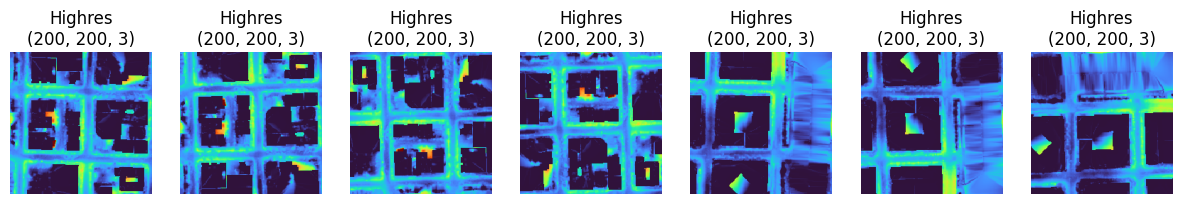

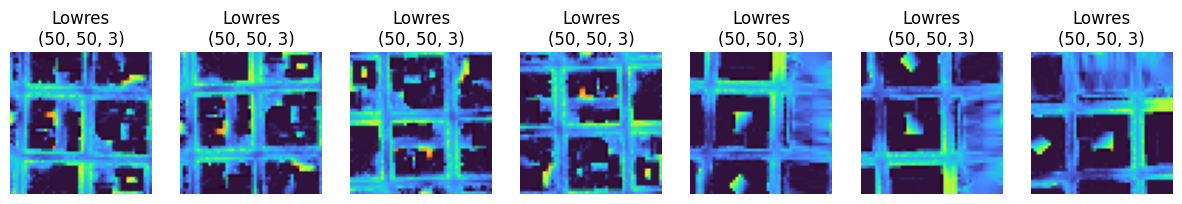

In [ ]:
lowres, highres = next(iter(train_ds))

# High Resolution Images
plt.figure(figsize=(15, 15))
for i in range(7):
    ax = plt.subplot(1, 7, i + 1)
    plt.imshow(highres[i].numpy().astype("uint8"))
    plt.title(f"Highres\n{highres[i].shape}")
    plt.axis("off")

# Low Resolution Images
plt.figure(figsize=(15, 15))
for i in range(7):
    ax = plt.subplot(1, 7, i + 1)
    plt.imshow(lowres[i].numpy().astype("uint8"))
    plt.title(f"Lowres\n{lowres[i].shape}")
    plt.axis("off")

In [ ]:
def PSNR(high_resolution, super_resolution):
    # Calculate PSNR
    return tf.image.psnr(high_resolution, super_resolution, max_val=255)

def SSIM(high_resolution, super_resolution, max_val=255):
    # Convert images to float32 (if not already) and normalize pixel values to [0, 1]
    high_resolution = tf.image.convert_image_dtype(high_resolution, tf.float32)
    super_resolution = tf.image.convert_image_dtype(super_resolution, tf.float32)

    # Calculate the mean SSIM value
    ssim_value = tf.image.ssim(high_resolution, super_resolution, max_val=max_val)

    return ssim_value

## FLO-SR model

In [ ]:
class EDSRModel(tf.keras.Model):
    def train_step(self, data):
        # Unpack the data. Its structure depends on your model and
        # on what you pass to `fit()`.
        x, y = data

        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)  # Forward pass
            # Compute the loss value
            # (the loss function is configured in `compile()`)
            loss = self.compiled_loss(y, y_pred, regularization_losses=self.losses)

        # Compute gradients
        trainable_vars = self.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        # Update weights
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
        # Update metrics (includes the metric that tracks the loss)
        self.compiled_metrics.update_state(y, y_pred)
        # Return a dict mapping metric names to current value
        return {m.name: m.result() for m in self.metrics}

    def predict_step(self, x):
        # Adding dummy dimension using tf.expand_dims and converting to float32 using tf.cast
        x = tf.cast(tf.expand_dims(x, axis=0), tf.float32)
        # Passing low resolution image to model
        super_resolution_img = self(x, training=False)
        # Clips the tensor from min(0) to max(255)
        super_resolution_img = tf.clip_by_value(super_resolution_img, 0, 255)
        # Rounds the values of a tensor to the nearest integer
        super_resolution_img = tf.round(super_resolution_img)
        # Removes dimensions of size 1 from the shape of a tensor and converting to uint8
        super_resolution_img = tf.squeeze(
            tf.cast(super_resolution_img, tf.uint8), axis=0
        )
        return super_resolution_img


# Residual Block
def ResBlock(inputs):
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.Add()([inputs, x])
    return x


# Upsampling Block
def Upsampling(inputs, factor=2, **kwargs):
    x = layers.Conv2D(64 * (factor ** 2), 3, padding="same", **kwargs)(inputs)
    x = tf.nn.depth_to_space(x, block_size=factor)
    x = layers.Conv2D(64 * (factor ** 2), 3, padding="same", **kwargs)(x)
    x = tf.nn.depth_to_space(x, block_size=factor)
    return x


def make_model(num_filters, num_of_residual_blocks):
    # Flexible Inputs to input_layer
    input_layer = layers.Input(shape=(None, None, 3))
    # Scaling Pixel Values
    x = layers.Rescaling(scale=1.0 / 255)(input_layer)
    x = x_new = layers.Conv2D(num_filters, 3, padding="same")(x)

    # 16 residual blocks
    for _ in range(num_of_residual_blocks):
        x_new = ResBlock(x_new)

    x_new = layers.Conv2D(num_filters, 3, padding="same")(x_new)
    x = layers.Add()([x, x_new])

    x = Upsampling(x)
    x = layers.Conv2D(3, 3, padding="same")(x)

    output_layer = layers.Rescaling(scale=255)(x)
    return EDSRModel(input_layer, output_layer)


model = make_model(num_filters=64, num_of_residual_blocks=16)

## Train the model

In [ ]:
import pickle

# Using adam optimizer with initial learning rate as 1e-4, changing learning rate after 5000 steps to 5e-5
optim_edsr = keras.optimizers.Adam(
    learning_rate=keras.optimizers.schedules.PiecewiseConstantDecay(
        boundaries=[5000], values=[1e-4, 5e-5]
    )
)
# Compiling model with loss as mean absolute error (L1 Loss) and metrics as PSNR and SSIM
model.compile(optimizer=optim_edsr, loss="mae", metrics=[PSNR, SSIM])

# Early stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience= 20,        # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restores model weights from the epoch with the best value of the monitored quantity
)

start_time = time.time()

# Training for more epochs will improve results
history = model.fit(train_ds, epochs=400, steps_per_epoch=100, validation_data=val_ds)

# Save the history
history_save_path = '/home/hchoi/SR3/EDSR/github_code/models/241024/Houston_4x_history.pkl'
os.makedirs(os.path.dirname(history_save_path), exist_ok=True)

with open(history_save_path, 'wb') as file_pi:
    pickle.dump(history.history, file_pi)

end_time = time.time()
training_time = end_time - start_time

# Save the model in the native Keras format
model_save_path = '/home/hchoi/SR3/EDSR/github_code/models/241024/Houston_4x_history.h5'
model.save(model_save_path)

print("Training time: {:.2f} seconds".format(training_time))

Epoch 1/400
100/100 [==============================] - 17s 49ms/step - loss: 38.0579 - PSNR: 15.0670 - SSIM: 0.1843 - val_loss: 21.9325 - val_PSNR: 17.9497 - val_SSIM: 0.3328
Epoch 2/400
100/100 [==============================] - 2s 24ms/step - loss: 17.3576 - PSNR: 19.6172 - SSIM: 0.4242 - val_loss: 16.7776 - val_PSNR: 19.8712 - val_SSIM: 0.4809
Epoch 3/400
100/100 [==============================] - 2s 24ms/step - loss: 14.3886 - PSNR: 20.7581 - SSIM: 0.5376 - val_loss: 14.1331 - val_PSNR: 20.7185 - val_SSIM: 0.5775
Epoch 4/400
100/100 [==============================] - 2s 24ms/step - loss: 12.7486 - PSNR: 21.4621 - SSIM: 0.6127 - val_loss: 12.6867 - val_PSNR: 21.2815 - val_SSIM: 0.6260
Epoch 5/400
100/100 [==============================] - 2s 24ms/step - loss: 11.7473 - PSNR: 21.8198 - SSIM: 0.6478 - val_loss: 11.8155 - val_PSNR: 21.6010 - val_SSIM: 0.6638
Epoch 6/400
100/100 [==============================] - 2s 24ms/step - loss: 10.8477 - PSNR: 22.2388 - SSIM: 0.6743 - val_loss: 11

100/100 [==============================] - 2s 24ms/step - loss: 7.6822 - PSNR: 23.4752 - SSIM: 0.8041 - val_loss: 8.0054 - val_PSNR: 23.1071 - val_SSIM: 0.7983
Epoch 49/400
100/100 [==============================] - 2s 24ms/step - loss: 7.6239 - PSNR: 23.4715 - SSIM: 0.8041 - val_loss: 7.9208 - val_PSNR: 23.1284 - val_SSIM: 0.8005
Epoch 50/400
100/100 [==============================] - 2s 24ms/step - loss: 7.4964 - PSNR: 23.6080 - SSIM: 0.8070 - val_loss: 8.2267 - val_PSNR: 23.1294 - val_SSIM: 0.8002
Epoch 51/400
100/100 [==============================] - 2s 24ms/step - loss: 7.4988 - PSNR: 23.5311 - SSIM: 0.8081 - val_loss: 7.8179 - val_PSNR: 23.1552 - val_SSIM: 0.8026
Epoch 52/400
100/100 [==============================] - 2s 24ms/step - loss: 7.5513 - PSNR: 23.4592 - SSIM: 0.8081 - val_loss: 7.8434 - val_PSNR: 23.1721 - val_SSIM: 0.8031
Epoch 53/400
100/100 [==============================] - 2s 24ms/step - loss: 7.4153 - PSNR: 23.5945 - SSIM: 0.8110 - val_loss: 7.8017 - val_PSNR: 23

100/100 [==============================] - 2s 24ms/step - loss: 6.9402 - PSNR: 24.0685 - SSIM: 0.8220 - val_loss: 7.3042 - val_PSNR: 23.6823 - val_SSIM: 0.8170
Epoch 96/400
100/100 [==============================] - 2s 24ms/step - loss: 7.0081 - PSNR: 24.0027 - SSIM: 0.8216 - val_loss: 7.2374 - val_PSNR: 23.7455 - val_SSIM: 0.8189
Epoch 97/400
100/100 [==============================] - 2s 24ms/step - loss: 6.8524 - PSNR: 24.1473 - SSIM: 0.8242 - val_loss: 7.1754 - val_PSNR: 23.7631 - val_SSIM: 0.8191
Epoch 98/400
100/100 [==============================] - 2s 24ms/step - loss: 6.8589 - PSNR: 24.1547 - SSIM: 0.8245 - val_loss: 7.2363 - val_PSNR: 23.7699 - val_SSIM: 0.8195
Epoch 99/400
100/100 [==============================] - 2s 24ms/step - loss: 6.8362 - PSNR: 24.1431 - SSIM: 0.8242 - val_loss: 7.1655 - val_PSNR: 23.8124 - val_SSIM: 0.8205
Epoch 100/400
100/100 [==============================] - 2s 24ms/step - loss: 6.8911 - PSNR: 24.0946 - SSIM: 0.8236 - val_loss: 7.1453 - val_PSNR: 2

100/100 [==============================] - 2s 24ms/step - loss: 6.3842 - PSNR: 24.6811 - SSIM: 0.8379 - val_loss: 6.7824 - val_PSNR: 24.3122 - val_SSIM: 0.8337
Epoch 143/400
100/100 [==============================] - 2s 24ms/step - loss: 6.3678 - PSNR: 24.6627 - SSIM: 0.8380 - val_loss: 6.7363 - val_PSNR: 24.3340 - val_SSIM: 0.8341
Epoch 144/400
100/100 [==============================] - 2s 24ms/step - loss: 6.4550 - PSNR: 24.6042 - SSIM: 0.8368 - val_loss: 6.6818 - val_PSNR: 24.3242 - val_SSIM: 0.8336
Epoch 145/400
100/100 [==============================] - 2s 24ms/step - loss: 6.2634 - PSNR: 24.7865 - SSIM: 0.8400 - val_loss: 6.7084 - val_PSNR: 24.3032 - val_SSIM: 0.8338
Epoch 146/400
100/100 [==============================] - 2s 24ms/step - loss: 6.4227 - PSNR: 24.6331 - SSIM: 0.8374 - val_loss: 6.7570 - val_PSNR: 24.3368 - val_SSIM: 0.8344
Epoch 147/400
100/100 [==============================] - 2s 24ms/step - loss: 6.3584 - PSNR: 24.6994 - SSIM: 0.8393 - val_loss: 6.6133 - val_PSN

100/100 [==============================] - 2s 24ms/step - loss: 5.9512 - PSNR: 25.1665 - SSIM: 0.8494 - val_loss: 6.3289 - val_PSNR: 24.7476 - val_SSIM: 0.8441
Epoch 190/400
100/100 [==============================] - 2s 24ms/step - loss: 6.1073 - PSNR: 25.0140 - SSIM: 0.8470 - val_loss: 6.3471 - val_PSNR: 24.7563 - val_SSIM: 0.8443
Epoch 191/400
100/100 [==============================] - 2s 24ms/step - loss: 6.0057 - PSNR: 25.0960 - SSIM: 0.8490 - val_loss: 6.2621 - val_PSNR: 24.7631 - val_SSIM: 0.8439
Epoch 192/400
100/100 [==============================] - 2s 24ms/step - loss: 5.9955 - PSNR: 25.0813 - SSIM: 0.8488 - val_loss: 6.2655 - val_PSNR: 24.7626 - val_SSIM: 0.8443
Epoch 193/400
100/100 [==============================] - 2s 24ms/step - loss: 5.8976 - PSNR: 25.2110 - SSIM: 0.8503 - val_loss: 6.3158 - val_PSNR: 24.7660 - val_SSIM: 0.8441
Epoch 194/400
100/100 [==============================] - 2s 24ms/step - loss: 6.0029 - PSNR: 25.1114 - SSIM: 0.8485 - val_loss: 6.2963 - val_PSN

100/100 [==============================] - 2s 24ms/step - loss: 5.7318 - PSNR: 25.4406 - SSIM: 0.8560 - val_loss: 5.9652 - val_PSNR: 25.1610 - val_SSIM: 0.8525
Epoch 237/400
100/100 [==============================] - 2s 24ms/step - loss: 5.6433 - PSNR: 25.5651 - SSIM: 0.8572 - val_loss: 6.0176 - val_PSNR: 25.1468 - val_SSIM: 0.8521
Epoch 238/400
100/100 [==============================] - 2s 24ms/step - loss: 5.7011 - PSNR: 25.4731 - SSIM: 0.8562 - val_loss: 6.0337 - val_PSNR: 25.1232 - val_SSIM: 0.8523
Epoch 239/400
100/100 [==============================] - 2s 24ms/step - loss: 5.7774 - PSNR: 25.4027 - SSIM: 0.8554 - val_loss: 5.9648 - val_PSNR: 25.1510 - val_SSIM: 0.8532
Epoch 240/400
100/100 [==============================] - 2s 24ms/step - loss: 5.6521 - PSNR: 25.5330 - SSIM: 0.8577 - val_loss: 5.9868 - val_PSNR: 25.1672 - val_SSIM: 0.8532
Epoch 241/400
100/100 [==============================] - 2s 24ms/step - loss: 5.6992 - PSNR: 25.5344 - SSIM: 0.8567 - val_loss: 6.1125 - val_PSN

100/100 [==============================] - 2s 24ms/step - loss: 5.5916 - PSNR: 25.6663 - SSIM: 0.8608 - val_loss: 5.7654 - val_PSNR: 25.4318 - val_SSIM: 0.8583
Epoch 284/400
100/100 [==============================] - 2s 24ms/step - loss: 5.4548 - PSNR: 25.8027 - SSIM: 0.8625 - val_loss: 5.7885 - val_PSNR: 25.3651 - val_SSIM: 0.8567
Epoch 285/400
100/100 [==============================] - 2s 24ms/step - loss: 5.4952 - PSNR: 25.7785 - SSIM: 0.8628 - val_loss: 5.7977 - val_PSNR: 25.4539 - val_SSIM: 0.8583
Epoch 286/400
100/100 [==============================] - 2s 24ms/step - loss: 5.4802 - PSNR: 25.7518 - SSIM: 0.8620 - val_loss: 5.8144 - val_PSNR: 25.3065 - val_SSIM: 0.8557
Epoch 287/400
100/100 [==============================] - 2s 24ms/step - loss: 5.5590 - PSNR: 25.6917 - SSIM: 0.8611 - val_loss: 5.8053 - val_PSNR: 25.2906 - val_SSIM: 0.8545
Epoch 288/400
100/100 [==============================] - 2s 24ms/step - loss: 5.4178 - PSNR: 25.8550 - SSIM: 0.8635 - val_loss: 5.8074 - val_PSN

100/100 [==============================] - 2s 24ms/step - loss: 5.3099 - PSNR: 25.9951 - SSIM: 0.8670 - val_loss: 5.5597 - val_PSNR: 25.7121 - val_SSIM: 0.8640
Epoch 331/400
100/100 [==============================] - 2s 24ms/step - loss: 5.3556 - PSNR: 25.9578 - SSIM: 0.8668 - val_loss: 5.5583 - val_PSNR: 25.7018 - val_SSIM: 0.8635
Epoch 332/400
100/100 [==============================] - 2s 24ms/step - loss: 5.2173 - PSNR: 26.1291 - SSIM: 0.8689 - val_loss: 5.6159 - val_PSNR: 25.6648 - val_SSIM: 0.8637
Epoch 333/400
100/100 [==============================] - 2s 24ms/step - loss: 5.3791 - PSNR: 25.9661 - SSIM: 0.8660 - val_loss: 5.6457 - val_PSNR: 25.6477 - val_SSIM: 0.8624
Epoch 334/400
100/100 [==============================] - 2s 24ms/step - loss: 5.3166 - PSNR: 26.0241 - SSIM: 0.8673 - val_loss: 5.5613 - val_PSNR: 25.6830 - val_SSIM: 0.8628
Epoch 335/400
100/100 [==============================] - 2s 24ms/step - loss: 5.3345 - PSNR: 25.9893 - SSIM: 0.8668 - val_loss: 5.5962 - val_PSN

100/100 [==============================] - 2s 24ms/step - loss: 5.2626 - PSNR: 26.1313 - SSIM: 0.8695 - val_loss: 5.4725 - val_PSNR: 25.8746 - val_SSIM: 0.8674
Epoch 378/400
100/100 [==============================] - 2s 24ms/step - loss: 5.1736 - PSNR: 26.2183 - SSIM: 0.8712 - val_loss: 5.4048 - val_PSNR: 25.8889 - val_SSIM: 0.8676
Epoch 379/400
100/100 [==============================] - 2s 24ms/step - loss: 5.2078 - PSNR: 26.1830 - SSIM: 0.8701 - val_loss: 5.4191 - val_PSNR: 25.9296 - val_SSIM: 0.8679
Epoch 380/400
100/100 [==============================] - 2s 24ms/step - loss: 5.1046 - PSNR: 26.3135 - SSIM: 0.8726 - val_loss: 5.4775 - val_PSNR: 25.8339 - val_SSIM: 0.8663
Epoch 381/400
100/100 [==============================] - 2s 24ms/step - loss: 5.1881 - PSNR: 26.1956 - SSIM: 0.8703 - val_loss: 5.4302 - val_PSNR: 25.8963 - val_SSIM: 0.8681
Epoch 382/400
100/100 [==============================] - 2s 24ms/step - loss: 5.2503 - PSNR: 26.1332 - SSIM: 0.8701 - val_loss: 5.4156 - val_PSN

/usr/local/python/anaconda3/envs/tensorflow-2.15/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## loss function and PSNR comparision plot

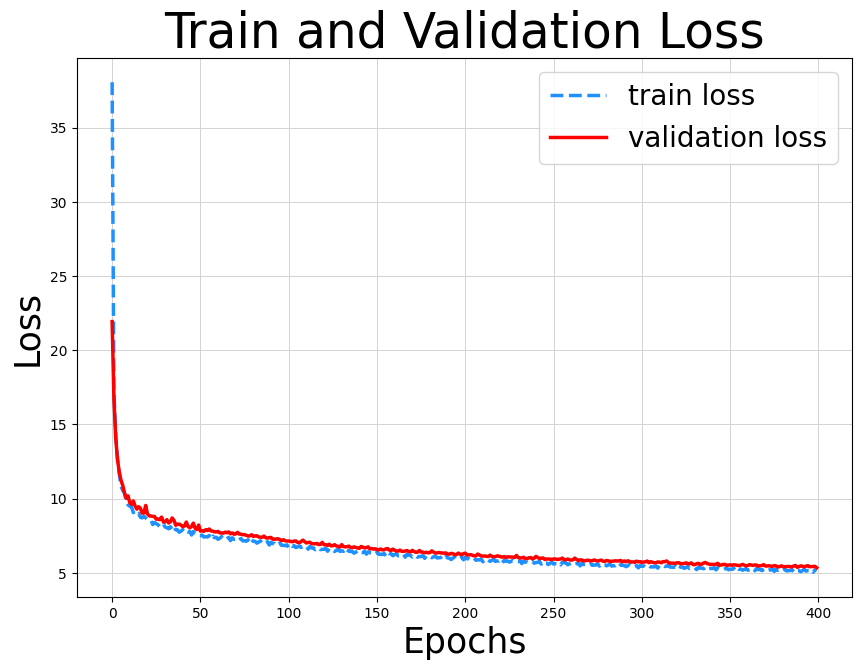

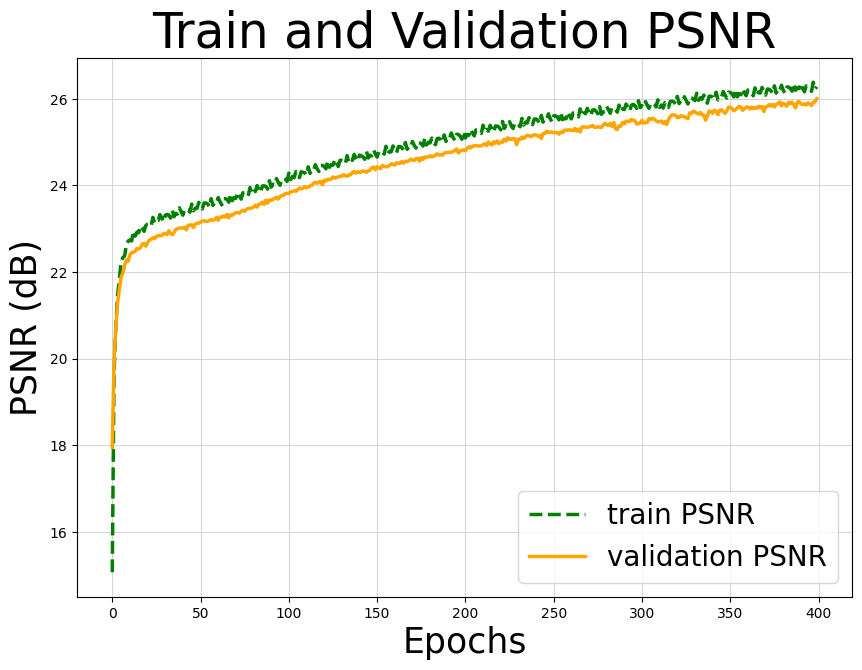

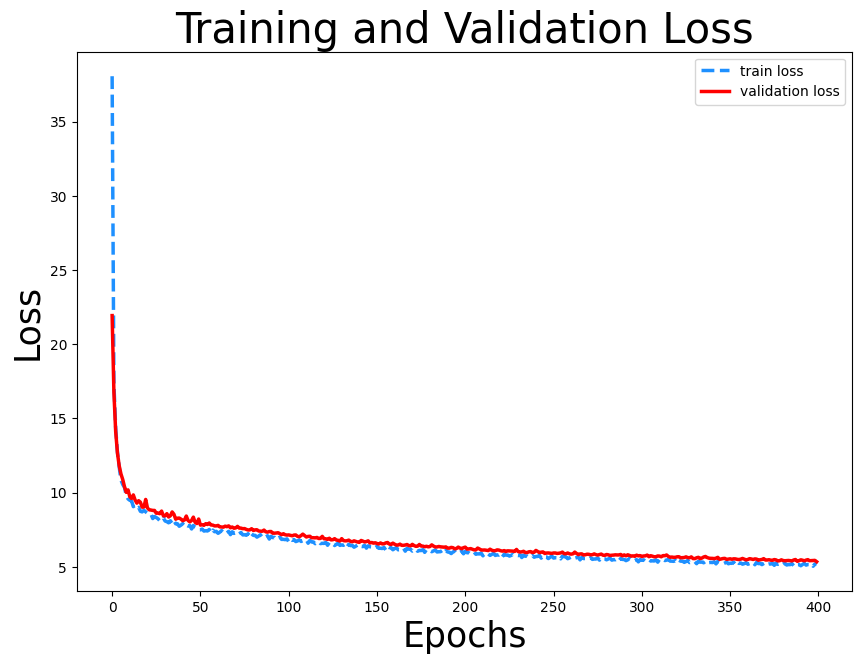

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting the training and validation loss
plt.figure(figsize=(10, 7))
plt.plot(history.history['loss'], color='dodgerblue', label='train loss', linewidth=2.5, linestyle="--")
plt.plot(history.history['val_loss'], color='red', label='validation loss', linewidth=2.5)
plt.xlabel('Epochs', size=25)
plt.ylabel('Loss', size=25)
plt.legend(fontsize=20)
plt.grid(color='lightgrey', linestyle='-', linewidth=0.7)
plt.title("Train and Validation Loss", size=35)
plt.show()

# Plotting the training and validation PSNR
plt.figure(figsize=(10, 7))
plt.plot(history.history['PSNR'], color='green', label='train PSNR', linewidth=2.5, linestyle="--")
plt.plot(history.history['val_PSNR'], color='orange', label='validation PSNR', linewidth=2.5)
plt.xlabel('Epochs', size=25)
plt.ylabel('PSNR (dB)', size=25)
plt.legend(fontsize=20, loc='lower right')
plt.grid(color='lightgrey', linestyle='-', linewidth=0.7)
plt.title("Train and Validation PSNR", size=35)
plt.show()

# Plotting the training and validation loss
plt.figure(figsize=(10, 7))
plt.plot(history.history['loss'], color='dodgerblue', label='train loss', linewidth=2.5, linestyle="--")
plt.plot(history.history['val_loss'], color='red', label='validation loss', linewidth=2.5)
plt.xlabel('Epochs', size=25)
plt.ylabel('Loss', size=25)
plt.title('Training and Validation Loss', size=30)
plt.legend()
plt.show()

## Save the output

In [ ]:
def save_image(image, filename):
    image = tf.clip_by_value(image, 0, 255)
    image = tf.cast(image, tf.uint8)
    image_encoded = tf.io.encode_png(image)
    tf.io.write_file(filename, image_encoded)

def plot_results(highres, lowres, preds, psnr, ssim):
    """
    Displays original high resolution image, low resolution image, and super resolution image
    """
    plt.figure(figsize=(24, 15))

    plt.subplot(131), plt.imshow(highres)
    plt.axis("off")
    plt.text(0.5, -0.15, "High resolution\n(PSNR / SSIM)".format(psnr, ssim),
             ha='center', fontsize=30, transform=plt.gca().transAxes, color='black')

    plt.subplot(132), plt.imshow(lowres)
    plt.axis("off")
    plt.text(0.5, -0.15, "Low resolution\n({:.4f} dB / {:.4f})".format(lr_psnr, lr_ssim),
             ha='center', fontsize=30, transform=plt.gca().transAxes, color='black')

    plt.subplot(133), plt.imshow(preds)
    plt.axis("off")
    plt.text(0.5, -0.15, "Super resolution\n({:.4f} dB / {:.4f})".format(sr_psnr, sr_ssim),
             ha='center', fontsize=30, transform=plt.gca().transAxes, color='black')

    plt.tight_layout()  # Reduce the margin between subplots

    return plt

# Function to calculate PSNR between two images
def calculate_sr_psnr(image, sr_image):
    return tf.image.psnr(image, sr_image, max_val=255)

def calculate_lr_psnr(image, hr_image):
    return tf.image.psnr(image, hr_image, max_val=255)

# Function to calculate SSIM between two images
def calculate_sr_ssim(image, sr_image):
    # Ensure that both images are of the same shape and format (numpy arrays)
    if isinstance(image, tf.Tensor):
        image = image.numpy()  # Convert TensorFlow tensor to numpy if needed
    if isinstance(sr_image, tf.Tensor):
        sr_image = sr_image.numpy()  # Convert TensorFlow tensor to numpy if needed

    # Check if the images are the same size
    if image.shape != sr_image.shape:
        raise ValueError(f"Image sizes are not the same: {image.shape} vs {sr_image.shape}")

    # Calculate SSIM with proper channel_axis for multi-channel images
    return ssim(image, sr_image, win_size=3, channel_axis=-1)

def calculate_lr_ssim(image, hr_image):
    if isinstance(image, tf.Tensor):
        image = image.numpy()  # Convert TensorFlow tensor to numpy if needed
    if isinstance(hr_image, tf.Tensor):
        hr_image = hr_image.numpy()  # Convert TensorFlow tensor to numpy if needed

    if image.shape != hr_image.shape:
        raise ValueError(f"Image sizes are not the same: {image.shape} vs {hr_image.shape}")

    return ssim(image, hr_image, win_size=3, channel_axis=-1)

# Define the folder to save SR results
output_folder = "/home/hchoi/SR3/EDSR/github_code/result/241024/Houston_4x/All/"
os.makedirs(output_folder, exist_ok=True)
preds_output_folder = "/home/hchoi/SR3/EDSR/github_code/result/241024/Houston_4x/SR/"
os.makedirs(preds_output_folder, exist_ok=True)
hr_output_folder = "/home/hchoi/SR3/EDSR/github_code/result/241024/Houston_4x/HR/"
os.makedirs(hr_output_folder, exist_ok=True)
lr_output_folder = "/home/hchoi/SR3/EDSR/github_code/result/241024/Houston_4x/LR/"
os.makedirs(lr_output_folder, exist_ok=True)
# Initialize the image number
image_num = 1

for lowres, highres in val_ds:
    batch_size = tf.shape(lowres)[0]
    crop_size = 50  # Adjust the crop size as needed
    lowres_cropped = tf.image.random_crop(lowres, (batch_size, crop_size, crop_size, 3))
    preds = []
    for i in range(batch_size):
        pred = model.predict_step(lowres_cropped[i])
        preds.append(pred)
    preds = tf.stack(preds)

    # Calculate PSNR and SSIM for each pair of images
    for i in range(batch_size):
        # Save HR image
        hr_filename = os.path.join(hr_output_folder, f"HR_{image_num}.png")
        save_image(highres[i], hr_filename)

        # Save LR image
        lr_filename = os.path.join(lr_output_folder, f"LR_{image_num}.png")
        save_image(lowres_cropped[i], lr_filename)

        # Save SR image
        pred_filename = os.path.join(preds_output_folder, f"SR_{image_num}.png")
        save_image(preds[i], pred_filename)

        sr_psnr = calculate_sr_psnr(highres[i], preds[i])
        sr_ssim = calculate_sr_ssim(highres[i].numpy(), preds[i].numpy())

        resized_lowres = tf.image.resize(lowres[i], size=(highres[i].shape[0], highres[i].shape[1]), method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

        lr_psnr = calculate_lr_psnr(resized_lowres, highres[i])
        lr_ssim = calculate_lr_ssim(resized_lowres.numpy(), highres[i].numpy())

        plt_output_path = os.path.join(output_folder, "plt_Result_{}.png".format(image_num))

        # Plot the results after calculating PSNR and SSIM
        plt = plot_results(highres[i], lowres[i], preds[i], sr_psnr, sr_ssim)

        # Save the plot to file with reduced margin
        plt.savefig(plt_output_path, bbox_inches='tight')
        plt.show()
        plt.close()  # Close the plot to avoid memory leakage

        print("PSNR between LR and SR image {}: {:.4f}".format(image_num, lr_psnr))
        print("SSIM between LR and SR image {}: {:.4f}".format(image_num, lr_ssim))
        print("PSNR between HR and SR image {}: {:.4f}".format(image_num, sr_psnr))
        print("SSIM between HR and SR image {}: {:.4f}".format(image_num, sr_ssim))

        # Increment the image number
        image_num += 1

Output hidden; open in https://colab.research.google.com to view.